# Required packages

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [4]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 5.1) Predicting the average weekly foot traffic in a retail store

In [5]:
foot_traffic = pd.read_csv('data/foot_traffic.csv')

In [6]:
foot_traffic

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695
...,...
995,706.009031
996,705.610549
997,704.771335
998,703.559920


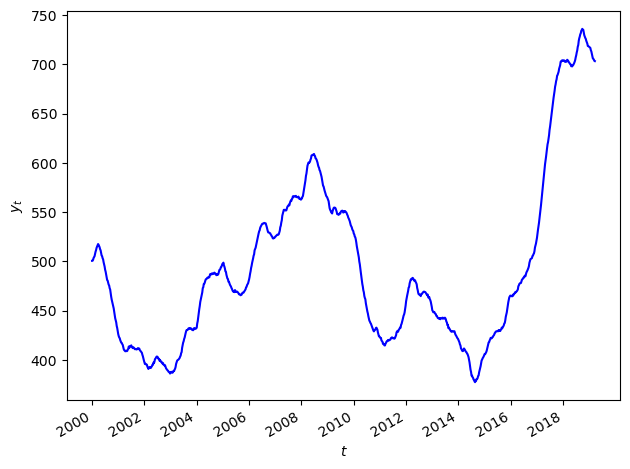

In [7]:
fig, ax = plt.subplots()
ax.plot(foot_traffic, 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [8]:
adfuller(foot_traffic.iloc[:, 0])

(np.float64(-1.1758885999240754),
 np.float64(0.6838808917896186),
 3,
 996,
 {'1%': np.float64(-3.4369325637409154),
  '5%': np.float64(-2.8644462162311934),
  '10%': np.float64(-2.568317409920808)},
 np.float64(2740.300875453594))

In [9]:
diff_foot_traffic = np.diff(foot_traffic.iloc[:, 0])

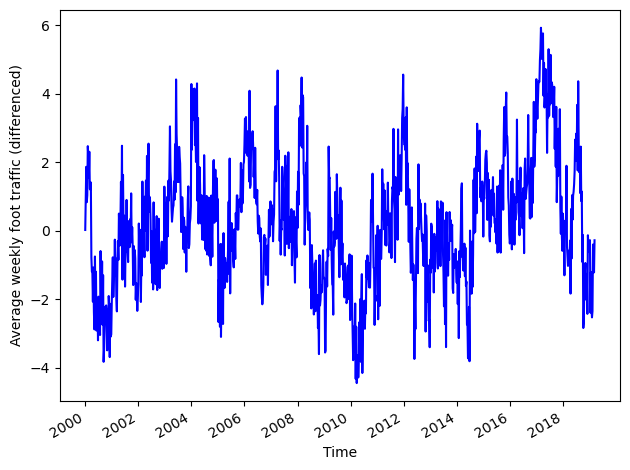

In [10]:
fig, ax = plt.subplots()
ax.plot(diff_foot_traffic, 'b-')
plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic (differenced)')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

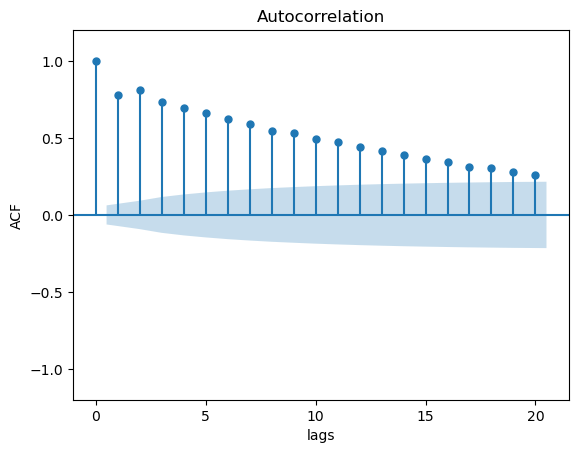

In [11]:
fig, ax = plt.subplots()
plot_acf(diff_foot_traffic, lags=20, ax=ax)
ax.set_xlabel('lags')
ax.set_ylabel('ACF')
ax.set_ylim([-1.2, 1.2])
plt.show()

In [12]:
adfuller(diff_foot_traffic)

(np.float64(-5.268231347422034),
 np.float64(6.3693176547816065e-06),
 2,
 996,
 {'1%': np.float64(-3.4369325637409154),
  '5%': np.float64(-2.8644462162311934),
  '10%': np.float64(-2.568317409920808)},
 np.float64(2735.535696297212))

# 5.3) Finding the order of a stationary autoregressive process

## 5.3.1) The partial autocorrelation function (PACF)

In [13]:
np.random.seed(42)
ma0 = np.array([1, 0, 0])
ar2 = np.array([1, -0.33, -0.50])
ar2_process = ArmaProcess(ar=ar2, ma=ma0).generate_sample(nsample=1000)

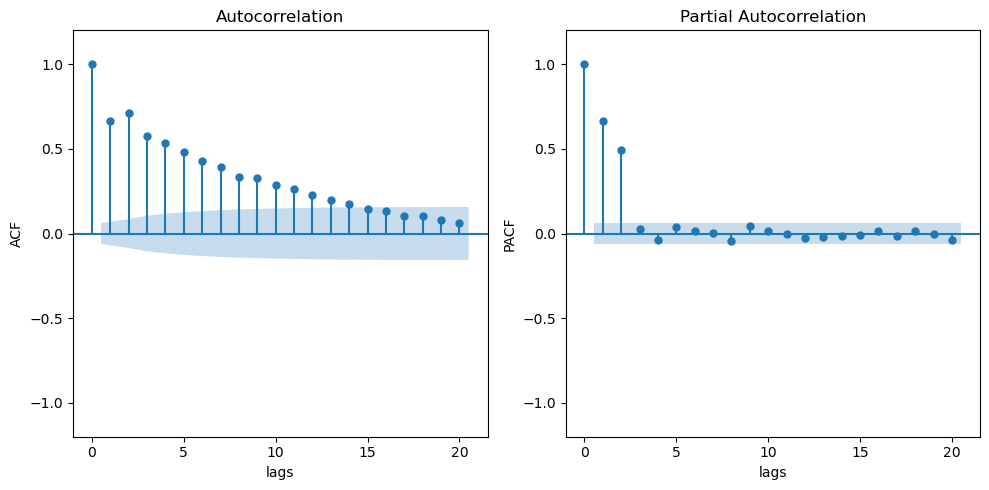

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
plot_acf(ar2_process, lags=20, ax=ax[0])
ax[0].set_ylim([-1.2, 1.2])
ax[0].set_xlabel('lags')
ax[0].set_ylabel('ACF')

plot_pacf(ar2_process, lags=20, ax=ax[1])
ax[1].set_ylim([-1.2, 1.2])
ax[1].set_xlabel('lags')
ax[1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

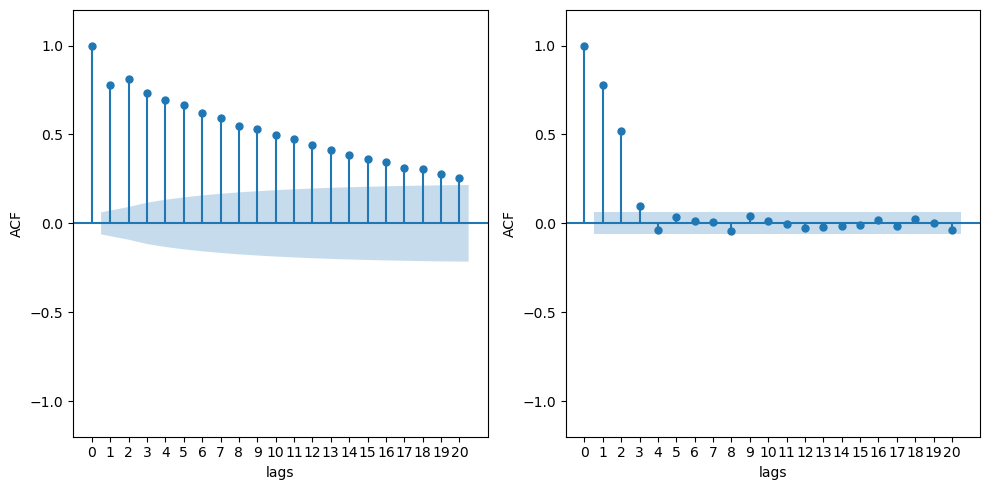

In [15]:
fig, ax = plt.subplot_mosaic([['acf', 'pacf']], figsize=(10, 5))
plot_acf(diff_foot_traffic, lags=20, ax=ax['acf'])
ax['acf'].set_xlabel('lags')
ax['acf'].set_ylabel('ACF')
ax['acf'].set_title('')
ax['acf'].set_xticks(np.arange(0, 21, 1))
ax['acf'].set_ylim([-1.2, 1.2])

plot_pacf(diff_foot_traffic, lags=20, ax=ax['pacf'])
ax['pacf'].set_xlabel('lags')
ax['pacf'].set_ylabel('ACF')
ax['pacf'].set_title('')
ax['pacf'].set_xticks(np.arange(0, 21, 1))
ax['pacf'].set_ylim([-1.2, 1.2])

plt.tight_layout()
plt.show()

# 5.4) Forecasting an autoregressive process

In [16]:
foot_traffic_diff = pd.DataFrame(diff_foot_traffic, columns=['foot_traffic_diff'])

In [17]:
train = foot_traffic_diff[:-52].copy()
test = foot_traffic_diff[-52:].copy()

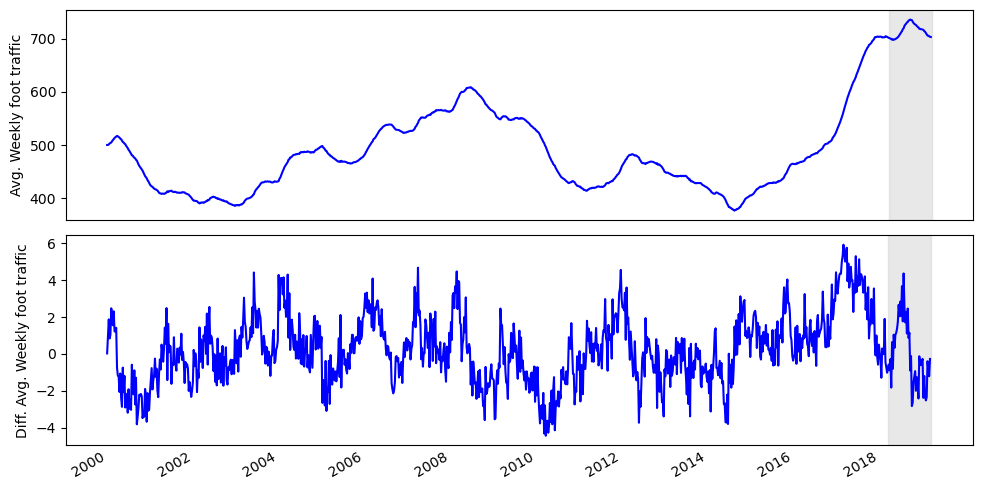

In [18]:
fig, ax = plt.subplot_mosaic([['foot'], ['foot_diff']], sharex=True, figsize=(10, 5))
ax['foot'].plot(foot_traffic, 'b-')
ax['foot'].set_ylabel('Avg. Weekly foot traffic')
ax['foot'].axvspan(1000-52, 1000, color='lightgray', alpha=0.5)
ax['foot'].tick_params(axis='x', length=0)

ax['foot_diff'].plot(foot_traffic_diff, 'b-')
ax['foot_diff'].set_ylabel('Diff. Avg. Weekly foot traffic')
ax['foot_diff'].axvspan(999-52, 999, color='lightgray', alpha=0.5)
ax['foot_diff'].tick_params(axis='x', length=0)

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Rolling forecast function

In [19]:
def rolling_forecast(df: pd.DataFrame, column: str, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

    It takes a DataFrame object with train and test data points.

    Args:
    -----
        df (pd.DataFrame): 
            DataFrame with all data points
        column (str):
            column to be forecast
        train_len (int): 
            number of data points used to fit the model 
        horizon (int):
            length of test set
        window (int):
            number of timesteps predicted at time
        method (str):
            specifies what model to use. It must be "last", "mean", "AR"

    Returns:
    --------
        list: predicted values
    """

    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
    
        for i in range(train_len, total_len, window):
            mean = np.mean(df.loc[:, column].iloc[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df.loc[:, column].iloc[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value

    if method == 'AR':
        pred_ar = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.loc[:, column].iloc[:i], order=(3,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ar.extend(oos_pred)
            
        return pred_ar

In [20]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

In [21]:
?rolling_forecast

Signature:
rolling_forecast(
    df: pandas.DataFrame,
    column: str,
    train_len: int,
    horizon: int,
    window: int,
    method: str,
) -> list
Docstring:
Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

It takes a DataFrame object with train and test data points.

Args:
-----
    df (pd.DataFrame): 
        DataFrame with all data points
    column (str):
        column to be forecast
    train_len (int): 
        number of data points used to fit the model 
    horizon (int):
        length of test set
    window (int):
        number of timesteps predicted at time
    method (str):
        specifies what model to use. It must be "last", "mean", "AR"

Returns:
--------
    list: predicted values
File:      /tmp/ipykernel_9971/2095786566.py
Type:      function

In [22]:
foot_traffic_diff.columns

Index(['foot_traffic_diff'], dtype='str')

In [23]:
test['mean'] = rolling_forecast(
    foot_traffic_diff, 'foot_traffic_diff', TRAIN_LEN, HORIZON, WINDOW, 'mean'
)

In [24]:
test['last'] = rolling_forecast(
    foot_traffic_diff, 'foot_traffic_diff', TRAIN_LEN, HORIZON, WINDOW, 'last'
)

In [25]:
test['AR'] = rolling_forecast(
    foot_traffic_diff, 'foot_traffic_diff', TRAIN_LEN, HORIZON, WINDOW, 'AR'
)

In [26]:
test.head()

,foot_traffic_diff,mean,last,AR
947,-0.776601,0.213270,-1.021893,-0.719714
948,-0.574631,0.212226,-0.776601,-0.814547
949,-0.890697,0.211397,-0.574631,-0.664738
950,-0.283552,0.210237,-0.890697,-0.641469
951,-1.830685,0.209717,-0.283552,-0.579279


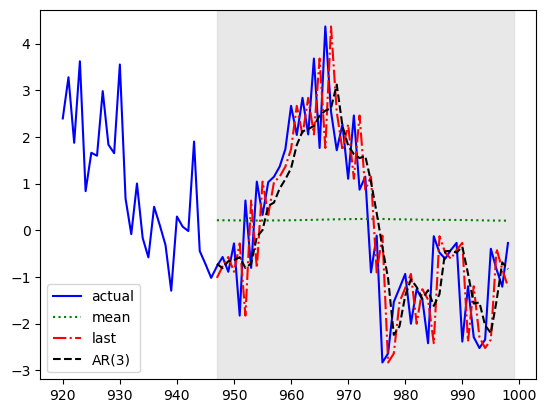

In [27]:
fig, ax = plt.subplots()
ax.plot(foot_traffic_diff[920:], 'b-', label='actual')
ax.plot(test['mean'], 'g:', label='mean')
ax.plot(test['last'], 'r-.', label='last')
ax.plot(test['AR'], 'k--', label='AR(3)')
ax.axvspan(999-52, 999, color='lightgray', alpha=0.5)
ax.legend()
plt.show()

In [28]:
metrics = pd.Series({
    'mean': mean_squared_error(test['foot_traffic_diff'], test['mean']),
    'last': mean_squared_error(test['foot_traffic_diff'], test['last']),
    'AR(3)': mean_squared_error(test['foot_traffic_diff'], test['AR'])
})

In [29]:
metrics

mean     3.107998
last     1.448730
AR(3)    0.924248
dtype: float64

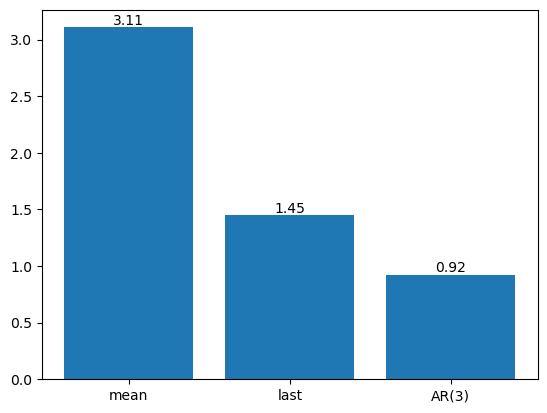

In [30]:
fig, ax = plt.subplots()
bars = ax.bar(metrics.index, metrics.values)
ax.bar_label(bars, fmt='%.2f')
plt.show()

### Undifferecing the time series

In [31]:
foot_traffic['pred'] = pd.Series()

In [32]:
foot_traffic.head()

,foot_traffic,pred
0,500.496714,NaN
1,500.522366,NaN
2,501.426876,NaN
3,503.295990,NaN
4,504.132695,NaN


In [33]:
foot_traffic.loc[948:, 'pred'] = np.array(foot_traffic.iloc[947, 0] + test['AR'].cumsum())

In [34]:
foot_traffic.iloc[947, 0] + test['AR'].cumsum()

947    701.743716
948    700.929169
949    700.264431
950    699.622962
951    699.043684
952    698.232950
953    697.519487
954    697.374513
955    697.377273
956    697.897335
957    698.488313
958    699.380573
959    700.472182
960    701.799662
961    703.625418
962    705.742387
963    707.906761
964    710.144076
965    712.600780
966    715.160670
967    717.775496
968    720.895194
969    723.129382
970    724.942997
971    726.573638
972    728.119028
973    729.707175
974    730.747169
975    731.112916
976    730.749754
977    729.710170
978    727.467199
979    725.410017
980    724.008107
981    722.955365
982    721.738326
983    720.265527
984    718.979101
985    717.356359
986    715.986231
987    715.532974
988    715.091262
989    714.610245
990    714.256564
991    713.323113
992    711.752553
993    710.203346
994    708.163326
995    705.958955
996    704.444262
997    703.754131
998    702.919983
Name: AR, dtype: float64

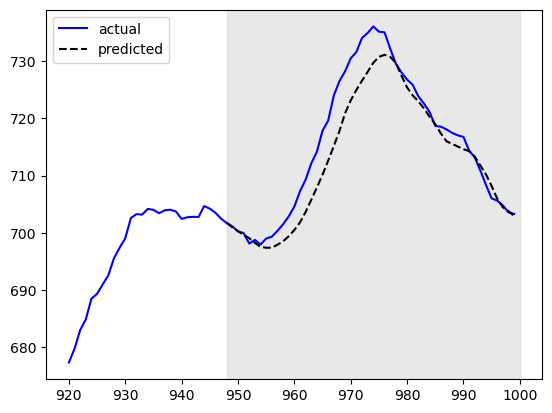

In [35]:
fig, ax = plt.subplots()
ax.plot(foot_traffic.loc[920:, 'foot_traffic'], 'b-', label='actual')
ax.plot(foot_traffic['pred'], 'k--', label='predicted')
ax.axvspan(1000-52, 1000, color='lightgray', alpha=0.5)
ax.legend()
plt.show()

In [36]:
foot_traffic.loc[948:, 'pred']

948    701.743716
949    700.929169
950    700.264431
951    699.622962
952    699.043684
953     698.23295
954    697.519487
955    697.374513
956    697.377273
957    697.897335
958    698.488313
959    699.380573
960    700.472182
961    701.799662
962    703.625418
963    705.742387
964    707.906761
965    710.144076
966     712.60078
967     715.16067
968    717.775496
969    720.895194
970    723.129382
971    724.942997
972    726.573638
973    728.119028
974    729.707175
975    730.747169
976    731.112916
977    730.749754
978     729.71017
979    727.467199
980    725.410017
981    724.008107
982    722.955365
983    721.738326
984    720.265527
985    718.979101
986    717.356359
987    715.986231
988    715.532974
989    715.091262
990    714.610245
991    714.256564
992    713.323113
993    711.752553
994    710.203346
995    708.163326
996    705.958955
997    704.444262
998    703.754131
999    702.919983
Name: pred, dtype: object

In [37]:
mean_absolute_error(foot_traffic.loc[948:, 'foot_traffic'], foot_traffic.loc[948:, 'pred'])

2.868797292806107